In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
from PIL import Image, ImageFilter, ImageEnhance

In [3]:
import os
import re


# Define base and output directories
base_dir = '/kaggle/input/ai-of-god-3/Public_data/test_images'
output_folder = '/kaggle/working/test_images'

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

def natural_sort_key(s):
    return [int(text) if text.isdigit() else text for text in re.split(r'(\d+)', s)]

# Iterate through each folder and process the images
for folder in sorted(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    page_number = folder
    
    if os.path.isdir(folder_path):
        for image_file in sorted(os.listdir(folder_path), key=natural_sort_key):
            if image_file.endswith('.png'):  
                image_path = os.path.join(folder_path, image_file)
                line_number = image_file.split('_')[-1].split('.')[0]
                
                # Define the output path for the processed image
                page_folder = os.path.join(output_folder, page_number)
                os.makedirs(page_folder, exist_ok=True)  # Create the page folder if it doesn't exist
                formatted_image_id = f'L_{line_number}.png'
                new_path = os.path.join(page_folder, formatted_image_id)
                
                # Open and process the image
                image = Image.open(image_path)

                # Convert the image to grayscale
                gray_image = image.convert('L')

                # Apply gentle sharpening
                sharpen_filter = ImageFilter.Kernel(
                    size=(3, 3),
                    kernel=[0, -1, 0, -1, 10, -1, 0, -1, 0],  # more gentle sharpening
                    scale=None,
                    offset=0
                )
                sharpened_image = gray_image.filter(sharpen_filter)

                # Denoising (optional: fine-tune the filter size)
                denoised_image = sharpened_image.filter(ImageFilter.MedianFilter(size=3))

                # Apply adaptive thresholding (to handle different lighting around text)
                binary_image = denoised_image.point(lambda p: 255 if p > 150 else 0)  # Adjust threshold dynamically

                # Save the processed image to the new path
                binary_image.save(new_path)

print("Image processing completed successfully!")

Image processing completed successfully!


In [4]:
!pip install verovio
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.1 MB/s eta 0:00:00


In [5]:
import os
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, AutoProcessor, ViTFeatureExtractor
import matplotlib.pyplot as plt
import re

In [6]:
processor = AutoProcessor.from_pretrained('qantev/trocr-large-spanish')
model = VisionEncoderDecoderModel.from_pretrained('qantev/trocr-large-spanish')

model = model.eval()

preprocessor_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.97k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

VisionEncoderDecoderModel has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


generation_config.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

In [7]:
base_dir = '/kaggle/working/test_images'
# base_dir = '/kaggle/input/ai-of-god-3/Public_data/test_images'
submission_df = pd.read_excel("/kaggle/input/ai-of-god-3/Public_data/submission.csv.xlsx")
submission_data = []

def apply_ocr(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    generated_ids = model.generate(pixel_values)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return generated_text

def apply_ocr2(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    generated_ids = model2.generate(pixel_values)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return generated_text

/opt/conda/lib/python3.10/site-packages/transformers/generation/utils.py:1338: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/transformers/generation/utils.py:1220: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Processed P_1_L_1: cru Señor por lus rectifsimos y ocul


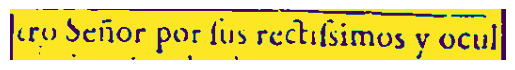

Processed P_1_L_2: los juvizios de darme tiempo, para


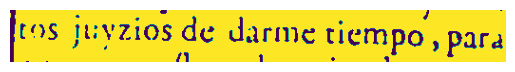

Processed P_1_L_3: que en vueftra educación lo mani


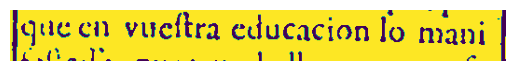

Processed P_1_L_4: tellaile, pues me hallo tantos mefes


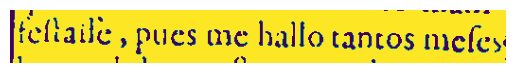

Processed P_1_L_5: ha rendida en ella cama, a vna en


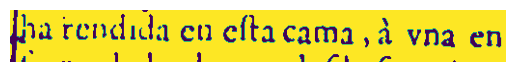

Processed P_1_L_6: termedad cal, que delde fu  princi-


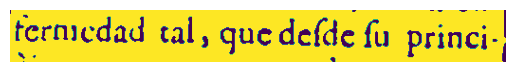

Processed P_1_L_7: pio me amenaza con la muerte, y


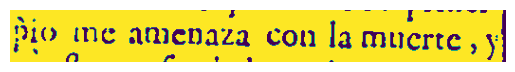

Processed P_1_L_8: vueltra  orfandad en tiernos años,


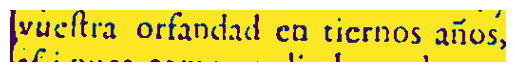

Processed P_1_L_9: áfí pues como os di al mundo con


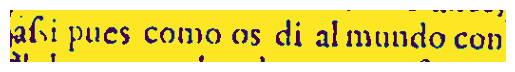

Processed P_1_L_10: Zlulores, con los de can penofos ac-


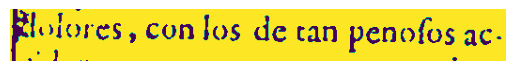

Processed P_1_L_11: cidenres, os  procuro  encaminar


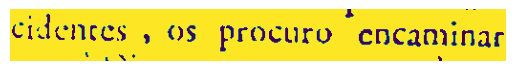

Processed P_1_L_12: aora à Lios, y que renazcays de mi


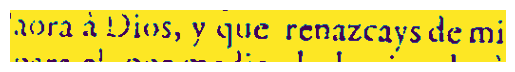

Processed P_1_L_13: para el, por medio de la virtud, à


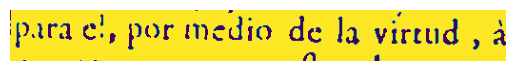

Processed P_1_L_14: jue os exorto con  eftos document


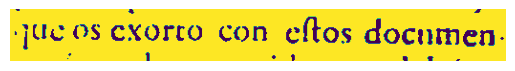

Processed P_1_L_15: us i que he recogido con el delue


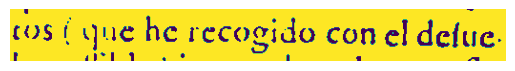

Processed P_1_L_16: lo pollible ) juzgando es la más elti


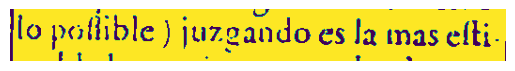

Processed P_1_L_17: nable berencia que puedo  dexaros


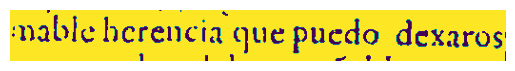

Processed P_1_L_18: en  prendas del  entrañable amor


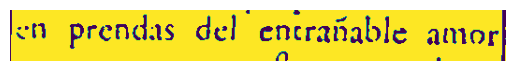

Processed P_1_L_19: que os tengo,por efte, y en primer


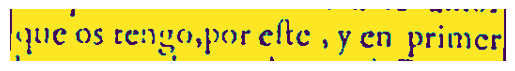

Processed P_1_L_20: lugar por el que deueys a Dios,os


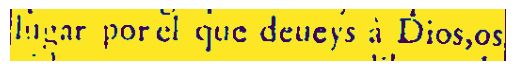

Processed P_1_L_21: pido, y encargo, que me libreys la


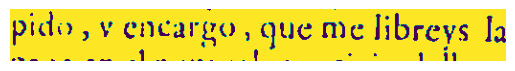

Processed P_1_L_22: paga en el puntual exercicio dellos,


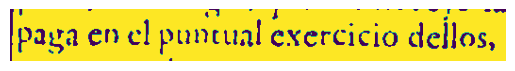

Processed P_1_L_23: v en premio us promero (con mi


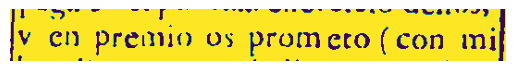

Processed P_1_L_24: bendición, que delile aqui os doy)


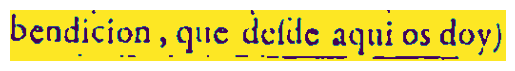

Processed P_2_L_1: de parte de Dios los doze más ex-


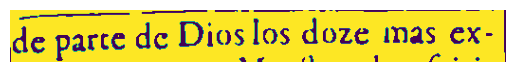

Processed P_2_L_2: celentes que un Maeltro de efpiri-


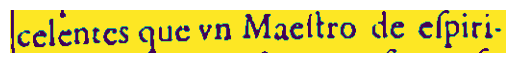

Processed P_2_L_3: tu largamente efcriue, y fon en fu


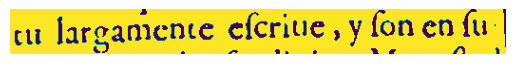

Processed P_2_L_4: ma:que tendra fu  diuina Mageltad


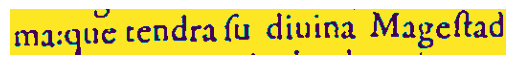

Processed P_2_L_5: providencia particular de volotros,


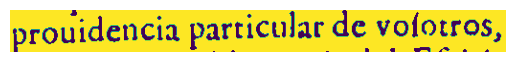

Processed P_2_L_6: y os concederá la gracia del  Efpiri


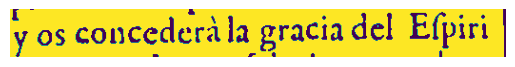

Processed P_2_L_7: tu Santo, fus confolaciones, y  lum-


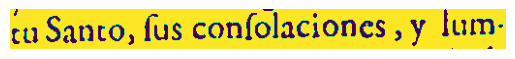

Processed P_2_L_8: bre fobrenatural, la alegría de la


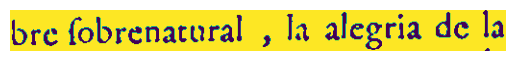

Processed P_2_L_9: buena conciencia, la efperanca en la


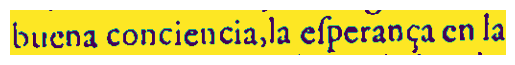

Processed P_2_L_10: diuina mifericordia, la verdadera li


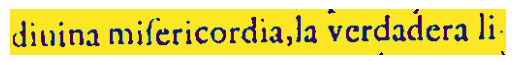

Processed P_2_L_11: bertad, y paz interior, oydo grato à


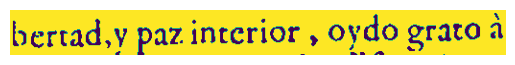

Processed P_2_L_12: vueltras oraciones, fu alliftencia, y


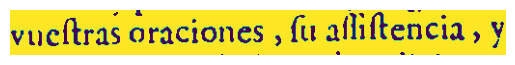

Processed P_2_L_13: fauor en los trabajos, y bendiciones


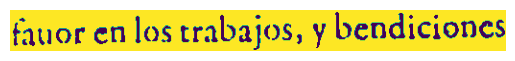

Processed P_2_L_14: que en la Santa  Elícritura  promete


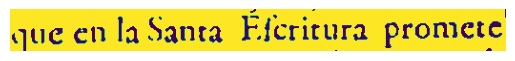

Processed P_2_L_15: i los virtuolos de rodo lo temporal,


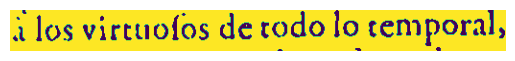

Processed P_2_L_16: y vltimamente, gloriofo y álegre


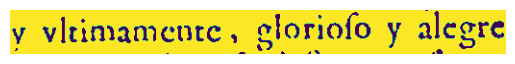

Processed P_2_L_17: tin, que cada cola dellas por lí pu-


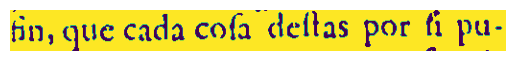

Processed P_2_L_18: diera fernos incenriuo para feguir


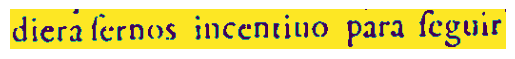

Processed P_2_L_19: el camino de la virtud, aunque no


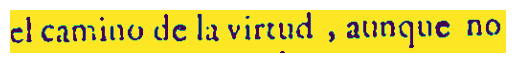

Processed P_2_L_20: vos tuuiera Dios de antemano o


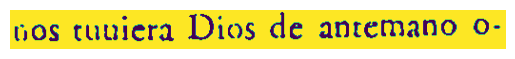

Processed P_2_L_21: bligados a clla, por fer el que es, y


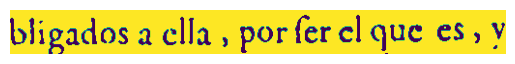

Processed P_2_L_22: por los ineftimables beneficios ge


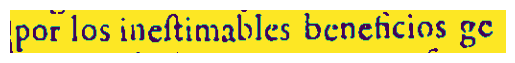

Processed P_2_L_23: nerales de la creación, conferua


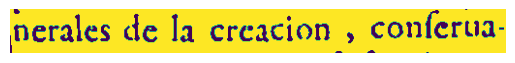

Processed P_2_L_24: cion, redempcion, juffificación, y


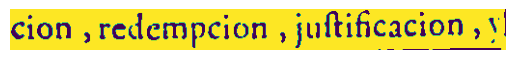

Processed P_3_L_1: predeftinación, à ó le añaden en ca-


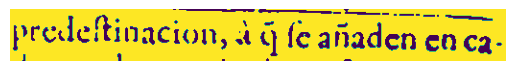

Processed P_3_L_2: la vno los particulares fuyos. Aqui


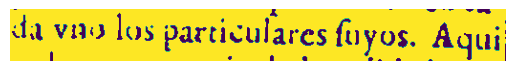

Processed P_3_L_3: os hayo memoria de la calidad que


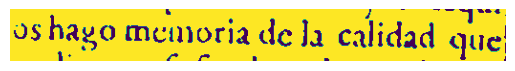

Processed P_3_L_4: os dio, que le funda en la excelencia


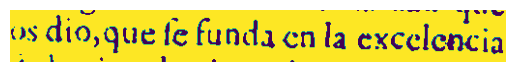

Processed P_3_L_5: de la virtud, origen de que le deriua


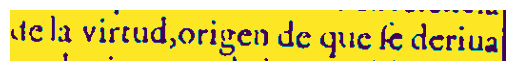

Processed P_3_L_6: qualquiera verdadera  nobleza, y


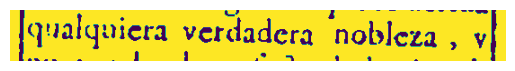

Processed P_3_L_7: pues es deuda, y efecto de la vireud,


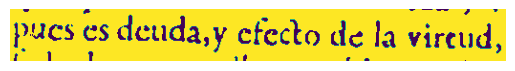

Processed P_3_L_8: led tales como ella  os  obliga a feri


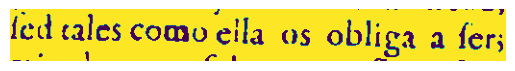

Processed P_3_L_9: mirad que no folo es necellaria,fino


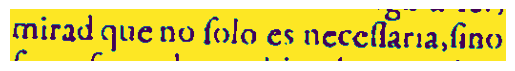

Processed P_3_L_10: forçofa en los nobles la virtud, y


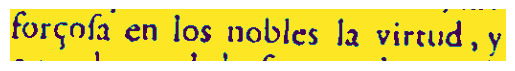

Processed P_3_L_11: que el que la bufca, es el  que le


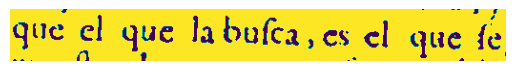

Processed P_3_L_12: mueltra de más generolo, y noble


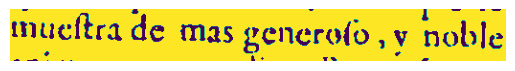

Processed P_3_L_13: animo, y como dixo  Bruno Sigui-


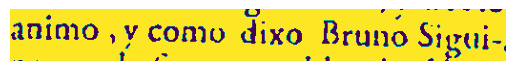

Processed P_3_L_14: no,puede ter más noble el efclaño


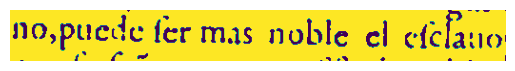

Processed P_3_L_15: que fu feñor,pues contilte la noble


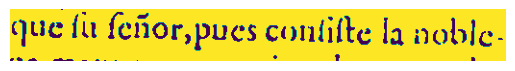

Processed P_3_L_16: za mayor en más virtud, y nace de


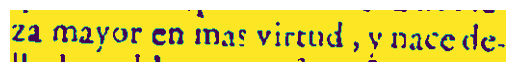

Processed P_3_L_17: Ila la nobleza, confcruafe en ella,


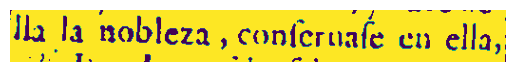

Processed P_3_L_18: quieda cadauer ti le falra, por ter el


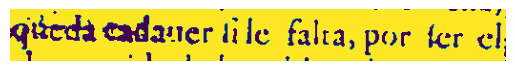

Processed P_3_L_19: alma, v vida de la nobleza la virrud,


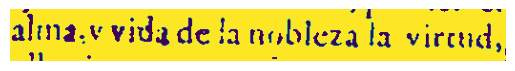

Processed P_3_L_20: ella tiene mayor fuerca que todas


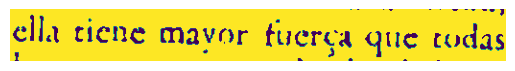

Processed P_3_L_21: las armas, y tan grande claridad, que


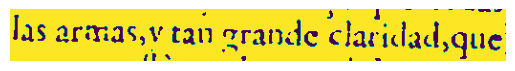

Processed P_3_L_22: aunque elte en lugar obticuro, a lí


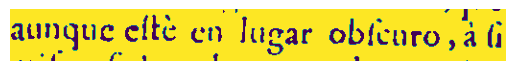

Processed P_3_L_23: milina fe haze luz como la más rica


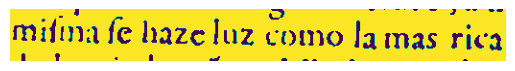

Processed P_3_L_24: de las piedras,ú es el Carbunco, fola


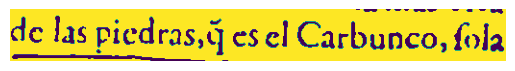

Processed P_4_L_1: ella es fuficieme premio del virtuo-


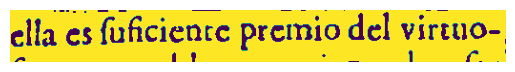

Processed P_4_L_2: fo:es ran noble, que ni  puede  vfar


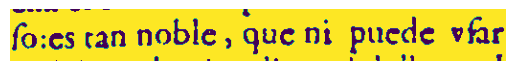

Processed P_4_L_3: mal de nada, ni nadie mal della, y  el


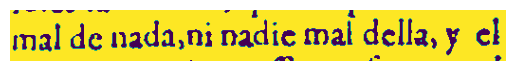

Processed P_4_L_4: fugero proprio, y alfienro luyo es el


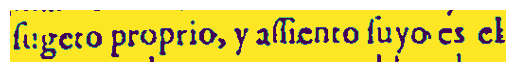

Processed P_4_L_5: más  excelente, pues en el hombre


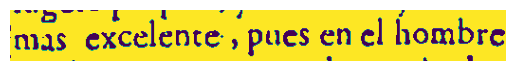

Processed P_4_L_6: es el coracon, y en el mundo  los


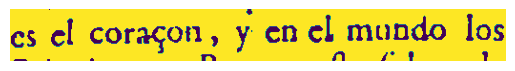

Processed P_4_L_7: Principes, y Reyes; efta fola es la


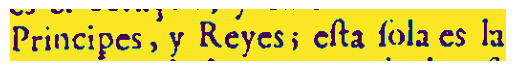

Processed P_4_L_8: que quita el  fencimiento de las ef-


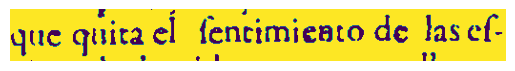

Processed P_4_L_9: pinas de la vida, y conera ella no


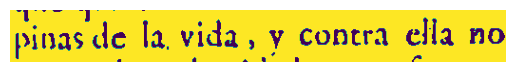

Processed P_4_L_10: rienen las calamidades más fuerza,


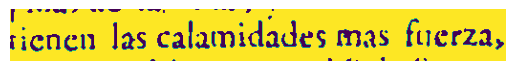

Processed P_4_L_11: que la niebla contra el Sol. Socra-


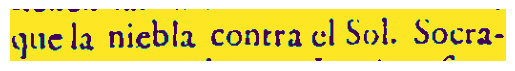

Processed P_4_L_12: ces  preguntado  por lorgias, fíte-


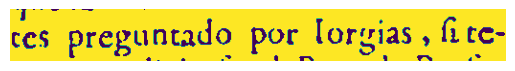

Processed P_4_L_13: nia por dicholo al Rey de Perfia,


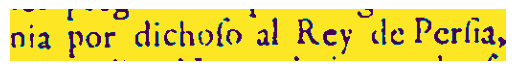

Processed P_4_L_14: relpondio: No puedo juzgar de el


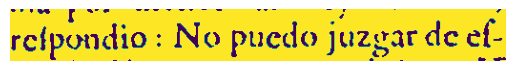

Processed P_4_L_15: fo, fin fabric quanta virtud tiene. Y


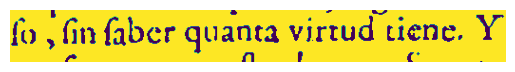

Processed P_4_L_16: conforma con ello lo que Seneca


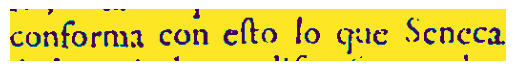

Processed P_4_L_17: delipues de largos difcurtos conclu-


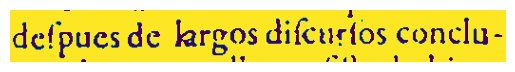

Processed P_4_L_18: yc, de que en ella contilte la bien-


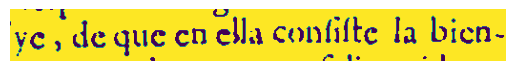

Processed P_4_L_19: auenturada, y más  feliz  vida, a


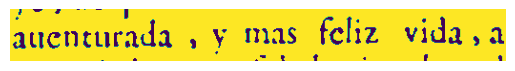

Processed P_4_L_20: que añade, que fola la virrud es el


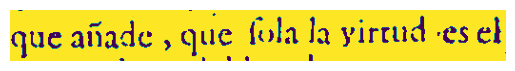

Processed P_4_L_21: propio bien del hombre, pues to


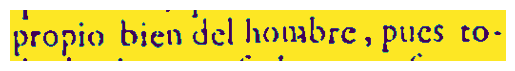

Processed P_4_L_22: das las demas colas humanas le con-


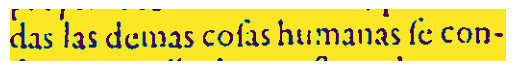

Processed P_4_L_23: fumen, y ella da mueftras de natu


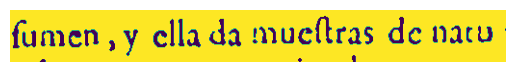

Processed P_4_L_24: raleza cterna, no suiendo otra  co-


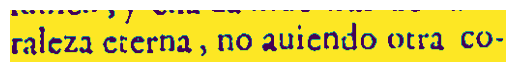

Processed P_5_L_1: pia (que procuran) pero (on más


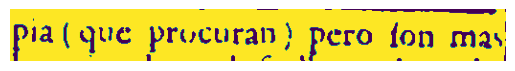

Processed P_5_L_2: los que  demandofe  lleuar de incli


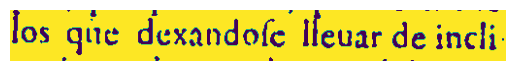

Processed P_5_L_3: naciones deprauadas, y aduladores


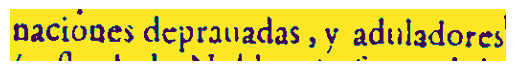

Processed P_5_L_4: (pelte de la Nobleza) vían mal de


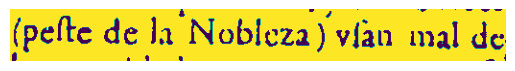

Processed P_5_L_5: la autoridad, y rentas con que le


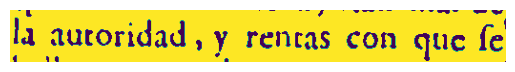

Processed P_5_L_6: hallan, comando por armas contra


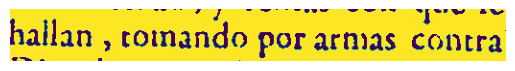

Processed P_5_L_7: Dios, las mercedes que del recibic-


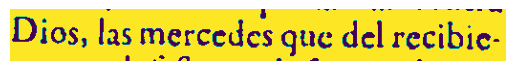

Processed P_5_L_8: ron, y  deléltimandofe, con lo que


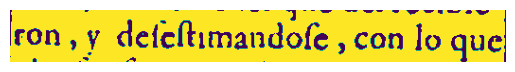

Processed P_5_L_9: pientan le engrandecen, pues en to


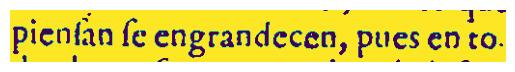

Processed P_5_L_10: das las colas quieren bondad fino


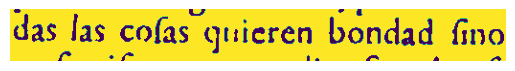

Processed P_5_L_11: en fí milmos, como dixo San Aguf-


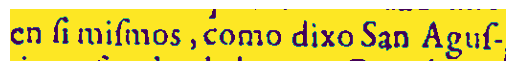

Processed P_5_L_12: tin: y tiendo de los que David dize


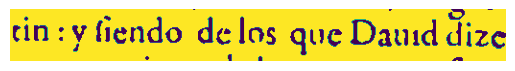

Processed P_5_L_13: no conocieron la honra en que fue


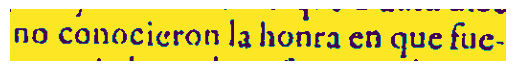

Processed P_5_L_14: ron criados, y la pulieron en lo  que


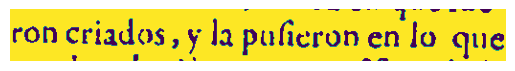

Processed P_5_L_15: más los abació, pues confilitiendo la


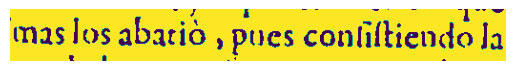

Processed P_5_L_16: verdadera en leruir, y agradar a


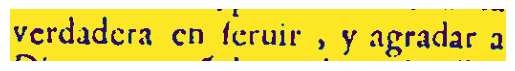

Processed P_5_L_17: Dios, venos ó dan en hazerle ellos


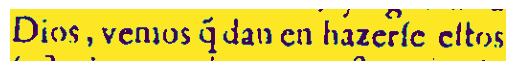

Processed P_5_L_18: lectarios, y cabecas  moltruolás  de


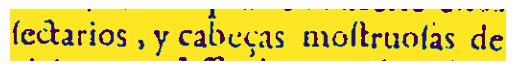

Processed P_5_L_19: vicios, profellando vnos la valen


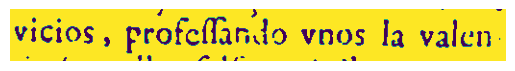

Processed P_5_L_20: cia ( en ellos falla y  ciuil ) otros (er


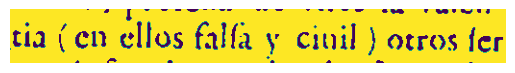

Processed P_5_L_21: graciofos, hurtando el oficio a los


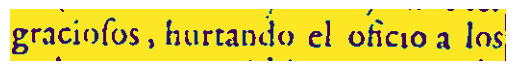

Processed P_5_L_22: truhanes, otros labios muy  por lo


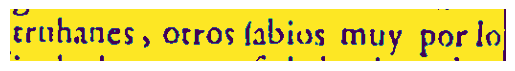

Processed P_5_L_23: inchadu, vnos enfadados de  rodos,


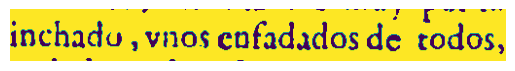

Processed P_5_L_24: y delcorteles, Poetas con arenos


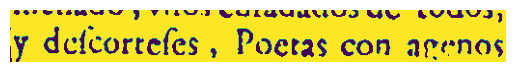

Processed P_6_L_1: verfos: los locos, y los que más lo


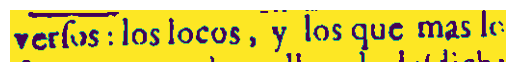

Processed P_6_L_2: fon, enamorados; y llega la deldicha


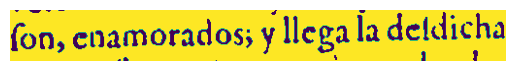

Processed P_6_L_3: de nuellros  tiempos à  ver baylor


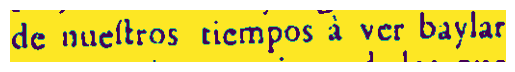

Processed P_6_L_4: como muigres, nieros de los que


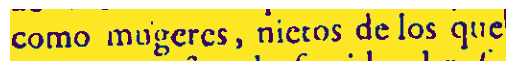

Processed P_6_L_5: truxeron cali toda fu vida el pelo


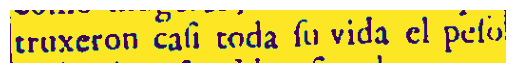

Processed P_6_L_6: de los Arnefes fobre fi, y las armas


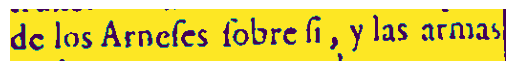

Processed P_6_L_7: en la mano, con que les ganaron


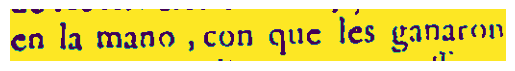

Processed P_6_L_8: lo que tan indignamente potleen.


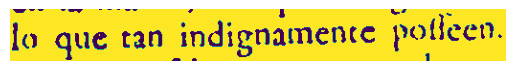

Processed P_6_L_9: Tampoco faltan otros, que hazen


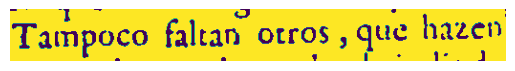

Processed P_6_L_10: gracia de exceder en los brindis de


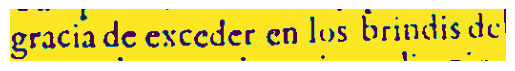

Processed P_6_L_11: los combires, y de no jugar limpio,


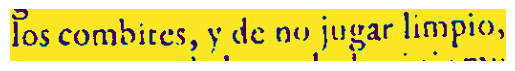

Processed P_6_L_12: ni tratar verdad; y gala de vivir múi


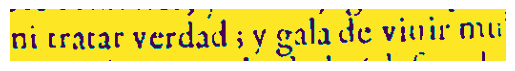

Processed P_6_L_13: chos años en mal cilado (delcuydo


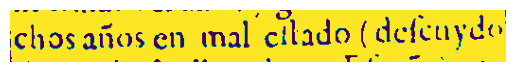

Processed P_6_L_14: digno de fer llorado en Elpaña; por


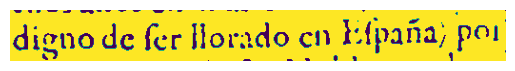

Processed P_6_L_15: la educación de fus Nobles, y el re


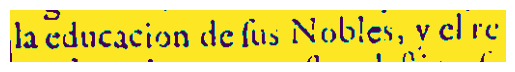

Processed P_6_L_16: prefentarle vo en eftas  láltimolas


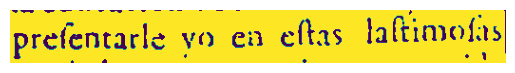

Processed P_6_L_17: verdades, es como pinraros aqui la


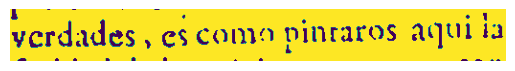

Processed P_6_L_18: fealdad de los vicios, para que con


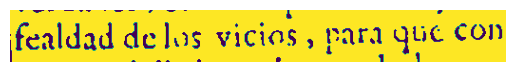

Processed P_6_L_19: horror della les cobreys el aborre


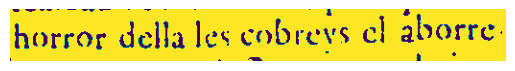

Processed P_6_L_20: cimiento que delleo, crevendo jun


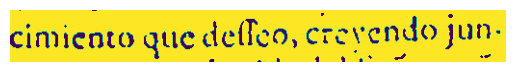

Processed P_6_L_21: tamente, que la vida del Señor grá


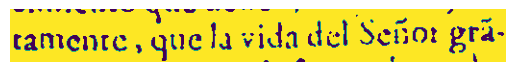

Processed P_6_L_22: de (no conren:andufe con huyr de


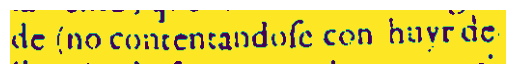

Processed P_6_L_23: llos) ha de fer un continuo exerci-


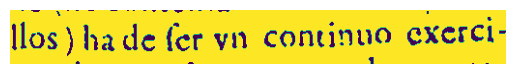

Processed P_6_L_24: cio de virtudes, porque la magna-


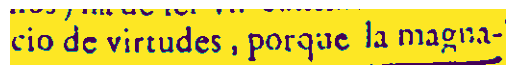

Processed P_7_L_1: nima forraleza, que es la propia, y


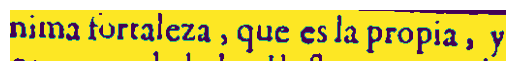

Processed P_7_L_2: connatural de los Iluftres, procede


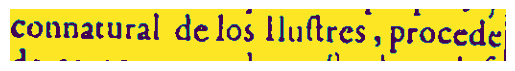

Processed P_7_L_3: de coracon grande, y clte deue del


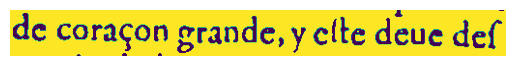

Processed P_7_L_4: preciar la boxeza mayor, que es el


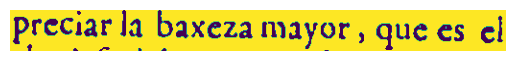

Processed P_7_L_5: abatrirfe à los vicios : fegún Arifto-


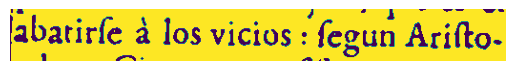

Processed P_7_L_6: tcles, y Ciceron, confille en tres co-


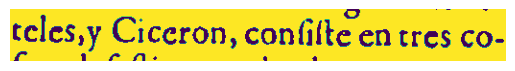

Processed P_7_L_7: las, defeltimar todas las exteriores,


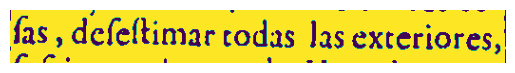

Processed P_7_L_8: fufrir mucho por la  Virtud, y por


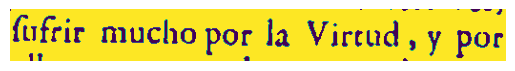

Processed P_7_L_9: ella acometer arduas y grandes em-


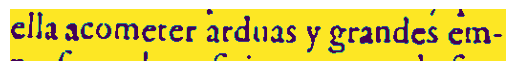

Processed P_7_L_10: prefas en beneficio comun: y la for


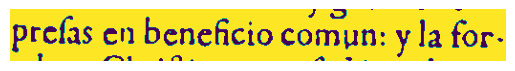

Processed P_7_L_11: taleza Christiana, es futrir, y hazer


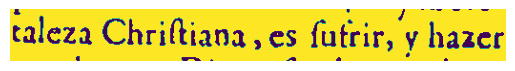

Processed P_7_L_12: mucho por Dios, y fu gloria, y bien


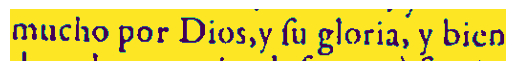

Processed P_7_L_13: de rodos, venciendofe vno à fí mil


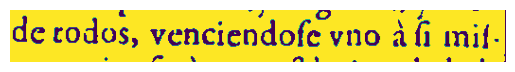

Processed P_7_L_14: mo, triunfo a que eftá vinculada la


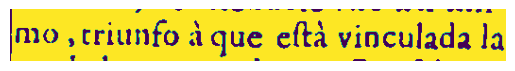

Processed P_7_L_15: verdadera  grandeza    Confiderad


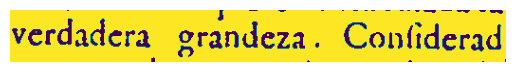

Processed P_7_L_16: pues, que la honra, y hazienda os la


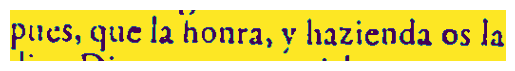

Processed P_7_L_17: dio  Dios para reparrirla, y  que


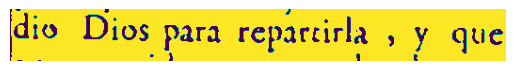

Processed P_7_L_18: auevs nacido canro para los demas,


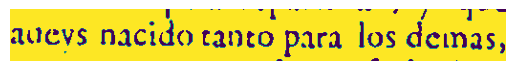

Processed P_7_L_19: como para vos milmo : afsi lo dixu


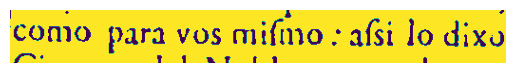

Processed P_7_L_20: Ciccron del Noble, y creed, que


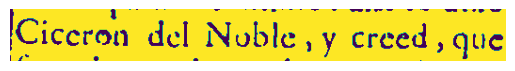

Processed P_7_L_21: Ion talentos de que le aueys de  dar


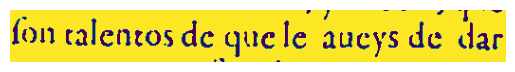

Processed P_7_L_22: cuenta muy eltrecha, y carga con


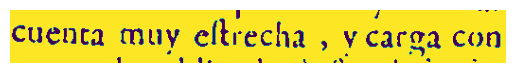

Processed P_7_L_23: que os ha obligado à fer detentor


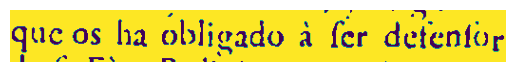

Processed P_7_L_24: de fu Fè y Religion,accerrimo per-


In [8]:
import matplotlib.image as mpimg

def natural_sort_key(s):
    return [int(text) if text.isdigit() else text for text in re.split(r'(\d+)', s)]

for folder in sorted(os.listdir(base_dir)):
    folder_path = os.path.join(base_dir, folder)
    page_number = folder.split('_')[-1]
    
    if os.path.isdir(folder_path):
        for image_file in sorted(os.listdir(folder_path), key=natural_sort_key):
            if image_file.endswith('.png'):  
                image_path = os.path.join(folder_path, image_file)
                line_number = image_file.split('_')[-1].split('.')[0]
                formatted_image_id = f'P_{page_number}_L_{line_number}'
                predicted_text = apply_ocr(image_path)
                
                # predicted_text = predicted_text.lower()
                
                submission_data.append({'unique Id': formatted_image_id, 'prediction': predicted_text})
                
                print(f"Processed {formatted_image_id}: {predicted_text}")
                if len(submission_data) < 168:   
                    img = mpimg.imread(image_path)  # Use mpimg to read the image
                    plt.imshow(img)  # Show the image in RGB format
                    plt.axis('off')  # Turn off the axis
                    
                    plt.show()

In [9]:
submission_df.rename(columns={'unique id': 'unique Id'}, inplace=True)

# Update predictions in the submission_df based on submission_data
for index, row in submission_df.iterrows():
    matching_prediction = next((pred for pred in submission_data if pred['unique Id'] == row['unique Id']), None)
    if matching_prediction:
        submission_df.at[index, 'prediction'] = matching_prediction['prediction']  

# Save the updated DataFrame to a CSV file
submission_df.to_csv('submission.csv', index=False)

print("Submission file created successfully")

Submission file created successfully


In [10]:
# Load the CSV file
submission_df = pd.read_csv('submission.csv')

# Display the first few rows of the file
print(submission_df.head())

  unique Id                            prediction
0   P_1_L_1  cru Señor por lus rectifsimos y ocul
1   P_1_L_2    los juvizios de darme tiempo, para
2   P_1_L_3      que en vueftra educación lo mani
3   P_1_L_4  tellaile, pues me hallo tantos mefes
4   P_1_L_5     ha rendida en ella cama, a vna en
